In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in
import numpy as np # linear algebra
import pandas as pd # data processing,
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os



In [26]:
# Importing data
Data =pd.read_csv(r'ASD_Toddler_dataset.csv')

In [27]:
#Displaying first and last five rows and all columns
Data

,BF1,BF2,BF3,BF4,BF5,BF6,BF7,BF8,BF9,BF10,Age_Mons,QchatBF1-10Score,Gender,Jaundice,Family_mem_with_ASD,Province,Class_ASD_Traits
0,0,0,0,0,0,0,1,1,0,1,28,3,f,yes,no,Harare,No
1,0,0,0,0,0,0,1,0,0,1,36,2,m,no,no,Harare,No
2,0,0,0,0,0,0,0,0,0,0,25,0,f,yes,no,Harare,No
3,0,0,0,0,0,0,0,0,0,0,18,0,m,no,no,Harare,No
4,0,0,0,0,0,0,0,0,0,0,36,0,m,no,yes,Harare,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3993,0,1,1,0,0,1,0,0,1,1,23,6,m,yes,no,Masvingo,Yes
3994,1,0,1,1,1,0,1,0,0,1,16,10,m,yes,no,Masvingo,Yes
3995,1,0,1,0,0,1,1,1,0,1,16,5,m,no,no,Masvingo,Yes
3996,1,0,1,1,0,1,1,0,0,1,27,1,m,no,yes,Masvingo,Yes


In [28]:
#Checking for missing values
print(Data.isnull().sum())

BF1                    0
BF2                    0
BF3                    0
BF4                    0
BF5                    0
BF6                    0
BF7                    0
BF8                    0
BF9                    0
BF10                   0
Age_Mons               0
QchatBF1-10Score       0
Gender                 0
Jaundice               0
Family_mem_with_ASD    0
Province               0
Class_ASD_Traits       0
dtype: int64


In [29]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3998 entries, 0 to 3997
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   BF1                  3998 non-null   int64 
 1   BF2                  3998 non-null   int64 
 2   BF3                  3998 non-null   int64 
 3   BF4                  3998 non-null   int64 
 4   BF5                  3998 non-null   int64 
 5   BF6                  3998 non-null   int64 
 6   BF7                  3998 non-null   int64 
 7   BF8                  3998 non-null   int64 
 8   BF9                  3998 non-null   int64 
 9   BF10                 3998 non-null   int64 
 10  Age_Mons             3998 non-null   int64 
 11  QchatBF1-10Score     3998 non-null   int64 
 12  Gender               3998 non-null   object
 13  Jaundice             3998 non-null   object
 14  Family_mem_with_ASD  3998 non-null   object
 15  Province             3998 non-null   object
 16  Class_

#### Exploratory Data Analysis

In [30]:
# Display summary statistics
print(Data.describe())

               BF1          BF2          BF3          BF4          BF5  \
count  3998.000000  3998.000000  3998.000000  3998.000000  3998.000000   
mean      0.545773     0.476238     0.438719     0.486743     0.504252   
std       0.497963     0.499498     0.496293     0.499887     0.500044   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       1.000000     0.000000     0.000000     0.000000     1.000000   
75%       1.000000     1.000000     1.000000     1.000000     1.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

               BF6          BF7          BF8          BF9         BF10  \
count  3998.000000  3998.000000  3998.000000  3998.000000  3998.000000   
mean      0.541771     0.564282     0.475738     0.497249     0.543772   
std       0.498314     0.495913     0.499473     0.500055     0.498143   
min       0.000000     0.000000     0

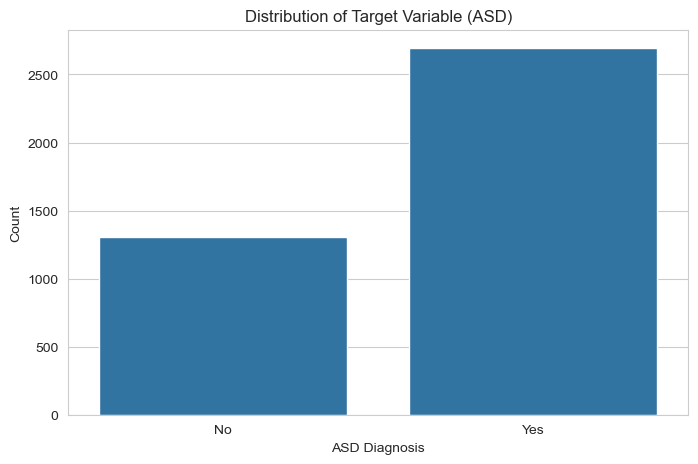

In [31]:
## Visualize the distribution of the target variable
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.countplot(x='Class_ASD_Traits ', data=Data)
plt.title('Distribution of Target Variable (ASD)')
plt.xlabel('ASD Diagnosis')
plt.ylabel('Count')
plt.show()

In [32]:
sns.set_style('whitegrid')
data1=Data[Data['Class_ASD_Traits ']=='Yes']
print("Toddlers", len(data1)/len(Data)*100)

Toddlers 67.38369184592297


#From this output we found that 67.38% of the toddlers in the dataset were positive in the ASD Diagnosis.

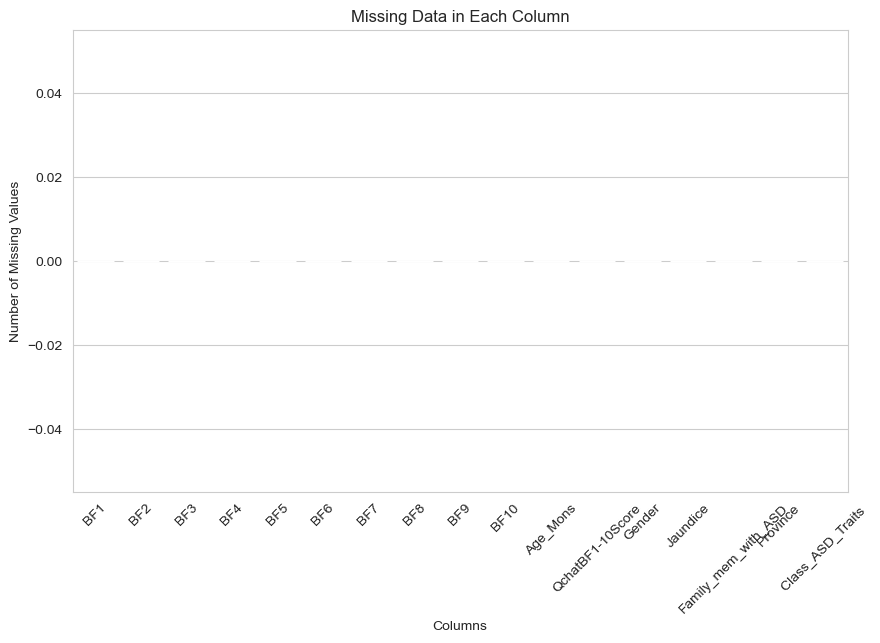

In [33]:
#Let's visualize the missing data
missing_data = Data.isnull().sum()

# Create a bar plot for missing values
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_data.index, y=missing_data.values)
plt.title('Missing Data in Each Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

#There were no null/missing values found


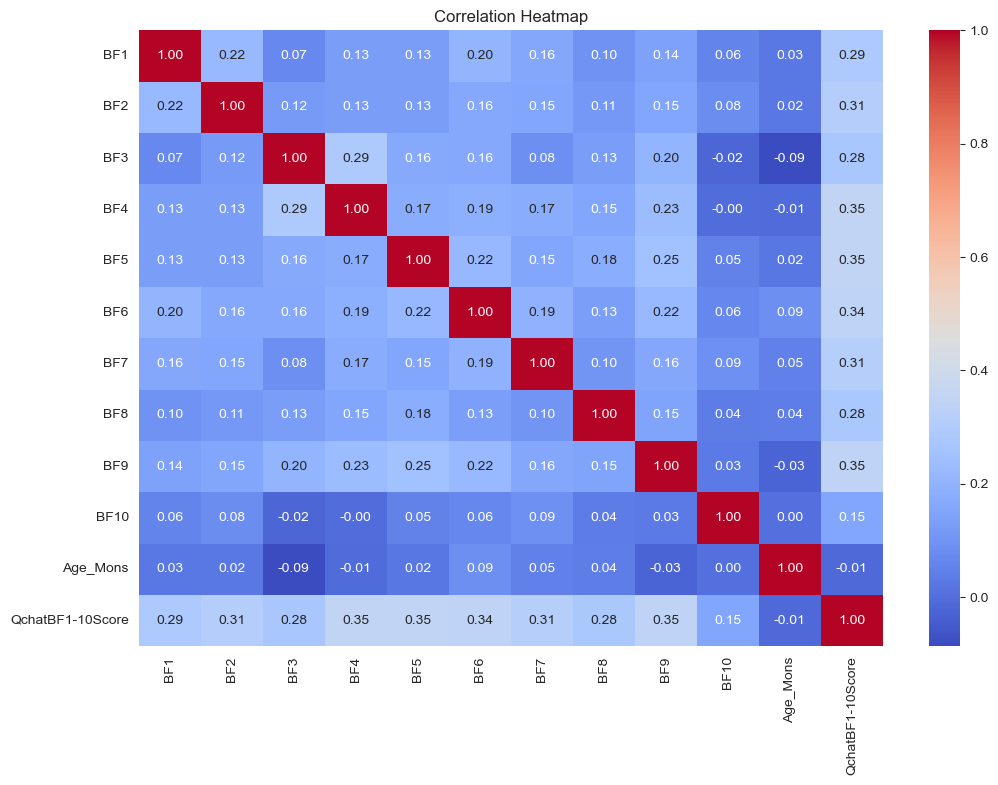

In [34]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
# Convert columns to numeric, errors='coerce' will replace non-numeric values with NaN
numeric_data = Data.apply(pd.to_numeric, errors='coerce')
# Drop columns with all NaN values after conversion
numeric_data = numeric_data.dropna(axis=1, how='all')
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#The highest correlation coefficient is 0.35, which is between BF4 and QchatBF1-10Score, BF5 and QchatBF1-10Score and BF9 and QchatBF1-10Score. The least correlation is between Age and QchatBF1-10Score.

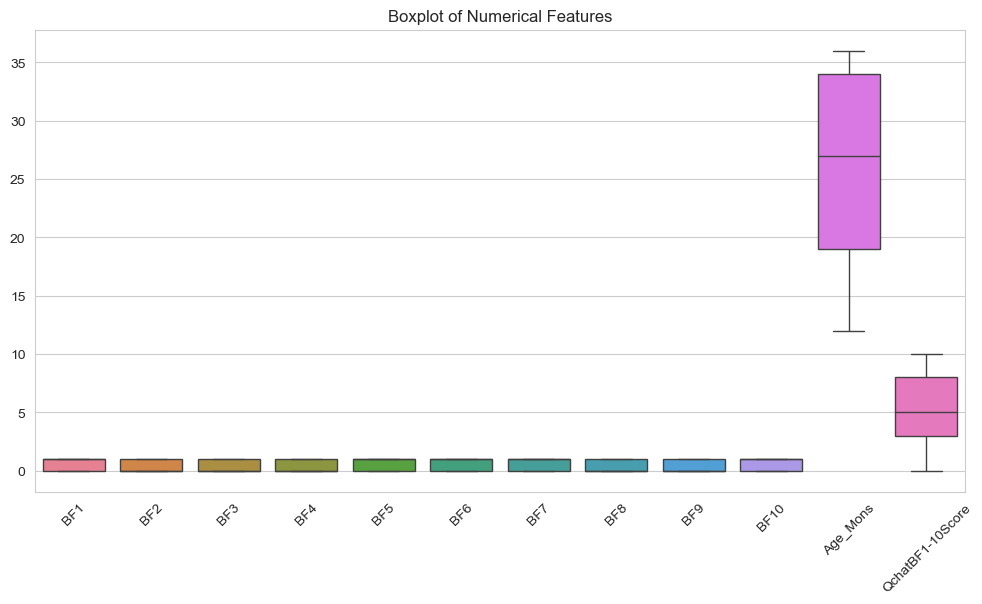

In [35]:
# Boxplot for numerical features
numerical_cols = ['BF1',	'BF2',	'BF3',	'BF4',	'BF5',	'BF6',	'BF7',	'BF8',	'BF9',	'BF10',	'Age_Mons',	'QchatBF1-10Score']
plt.figure(figsize=(12, 6))
sns.boxplot(data=Data[numerical_cols])
plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=45)
plt.show()

There were no outliers identified in BF1 to BF10

#EXPLORATORY DATA ANALYSIS

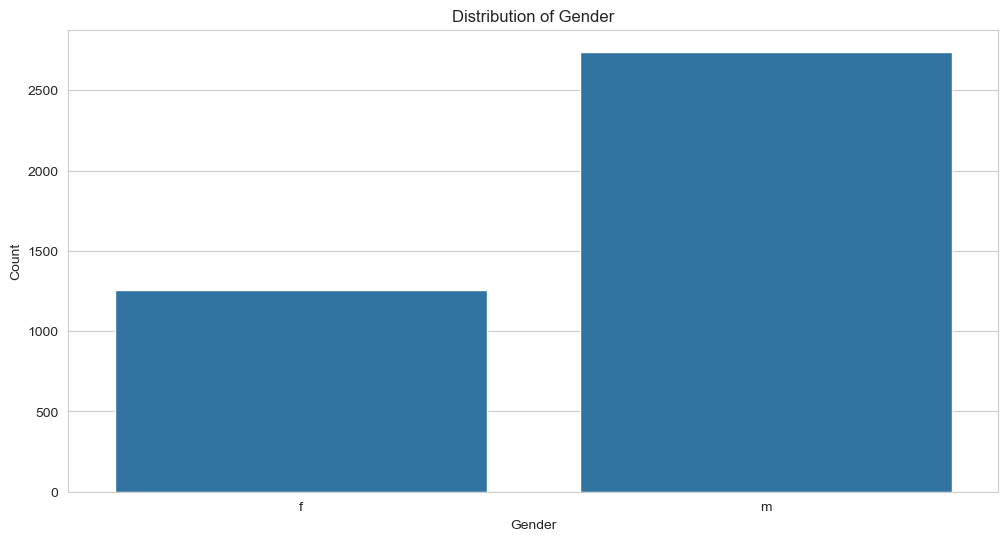

In [36]:
# Countplot for GENDER
plt.figure(figsize=(12, 6))
sns.countplot(x='Gender', data=Data)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

#The countplot shows that there are around 1350 males in contrast to around 620 females in the data.

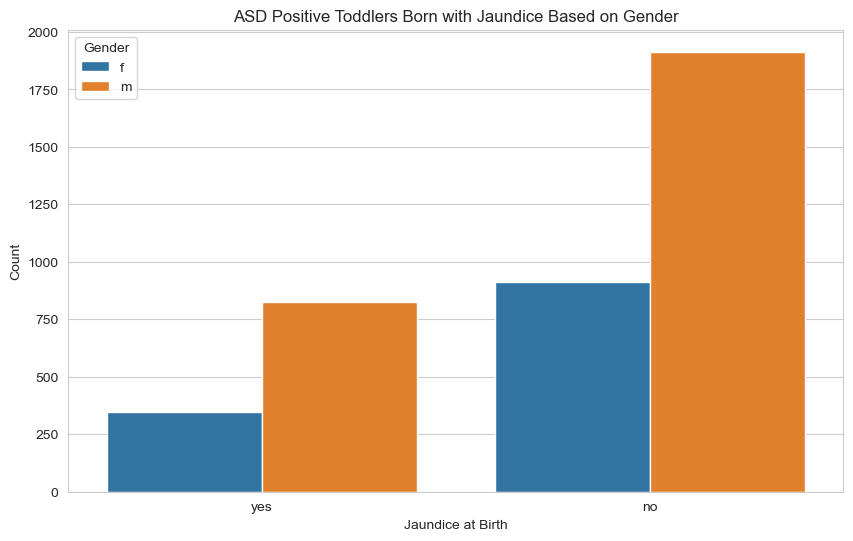

In [37]:
#visualizing the jaundice born toddlers based on gender
plt.figure(figsize=(10, 6))

# Create countplot for jaundice based on gender
sns.countplot(x='Jaundice', data=Data, hue='Gender')

# Set the title and labels
plt.title('ASD Positive Toddlers Born with Jaundice Based on Gender')
plt.xlabel('Jaundice at Birth')
plt.ylabel('Count')

# Show the plot
plt.show()

Generally more ASD positive toddlers are born without jaundice.

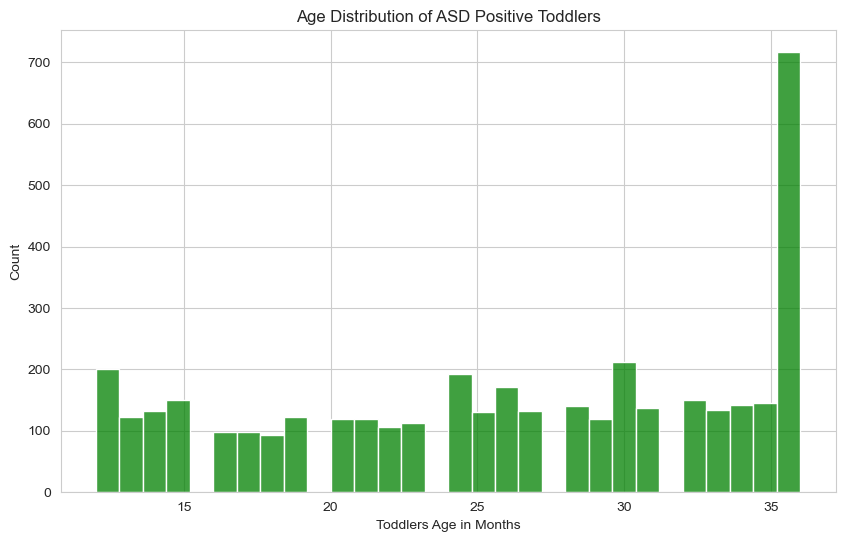

In [38]:
#Visualizing the age distribution of ASD positive
plt.figure(figsize=(10, 6))

# Create the distribution plot for Age_Mons
sns.histplot(Data['Age_Mons'], bins=30, color='green', kde=False)

# Set the title and labels
plt.xlabel('Toddlers Age in Months')
plt.title('Age Distribution of ASD Positive Toddlers')

# Show the plot
plt.show()

From this output, it is vivid that ASD is most common in 36 months old toddlers.

In [39]:
#Visualizing the province value counts

data1['Province'].value_counts()

Province
Masvingo               896
Harare                 656
Manicaland             380
Midlands               242
Bulawayo               176
Mashonaland East       124
Matebelend South       110
Matebelend North        88
Mashonaland central     22
Name: count, dtype: int64

Most toddlers in this study are from Masvingo Province and Mashonaland central has the least.

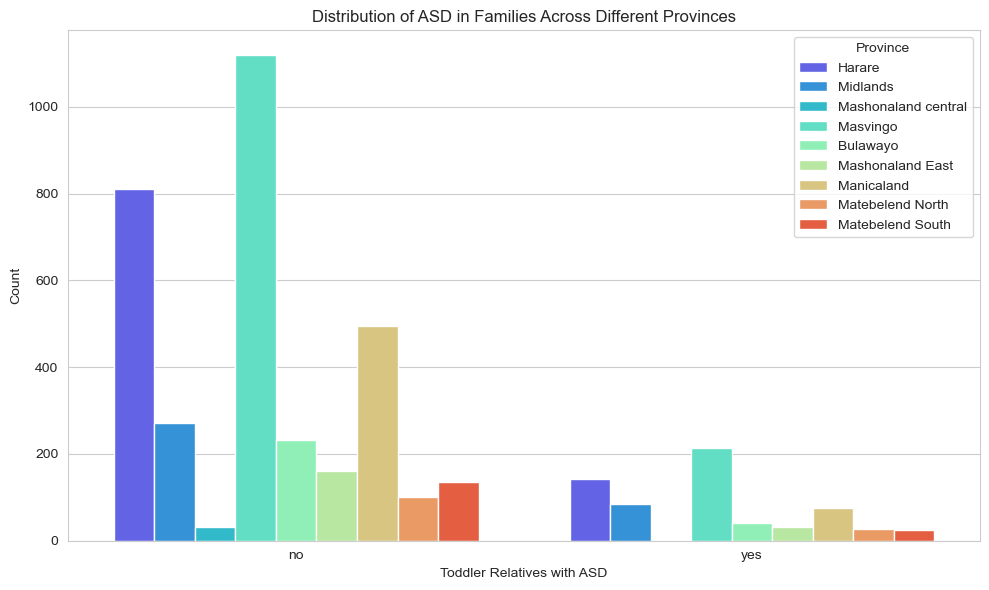

In [40]:
#visualizing the distribution of autism in family within different provinces
plt.figure(figsize=(10, 6))

# Create countplot for Family_mem_with_ASD with hue for Province
sns.countplot(x='Family_mem_with_ASD', data=Data, hue='Province', palette='rainbow')

# Set the title and labels
plt.title('Distribution of ASD in Families Across Different Provinces')
plt.xlabel('Toddler Relatives with ASD')
plt.ylabel('Count')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

The majority of families in Mashonaland Central followed by Harare have no family member with ASD.

#### Feature Engeneering

In [41]:
#Creating a dummy variable
within24_36= pd.get_dummies(Data['Age_Mons']>24,drop_first=True)
within0_12 = pd.get_dummies(Data['Age_Mons']<13,drop_first=True)
male=pd.get_dummies(Data['Gender'],drop_first=True)
province=pd.get_dummies(Data['Province'],drop_first=True)
jaundice=pd.get_dummies(Data['Jaundice'],drop_first=True)
ASD_genes=pd.get_dummies(Data['Family_mem_with_ASD'],drop_first=True)
ASD_traits=pd.get_dummies(Data['Class_ASD_Traits '],drop_first=True)

In [42]:
#Assuming the dataframes within0_12, within24_36, male, province, jaundice, ASD_genes, ASD_traits are defined elsewhere
final_data=pd.concat([within0_12, within24_36, male, province, jaundice, ASD_genes, ASD_traits], axis=1)
# Assigning new column names to the final_data DataFrame
final_data.columns=['within0_12','within24_36','male','Harare','Mashonaland central','Masvingo','Midlands','Matebeleland North','Matebeleland South','Mashonaland East','Bulawayo','jaundice','ASD_genes','ASD_traits']
#Display the first few rows of the final_data DataFrame
final_data.head()

,within0_12,within24_36,male,Harare,Mashonaland central,Masvingo,Midlands,Matebeleland North,Matebeleland South,Mashonaland East,Bulawayo,jaundice,ASD_genes,ASD_traits
0,False,True,False,True,False,False,False,False,False,False,False,True,False,False
1,False,True,True,True,False,False,False,False,False,False,False,False,False,False
2,False,True,False,True,False,False,False,False,False,False,False,True,False,False
3,False,False,True,True,False,False,False,False,False,False,False,False,False,False
4,False,True,True,True,False,False,False,False,False,False,False,False,True,False


In [43]:
#data normalization for numerical
import pandas as pd

def min_max_scaling(df, column_name):
  """
  Normalizes a numerical column using min-max scaling.

  Args:
    df: The DataFrame containing the data.
    column_name: The name of the column to normalize.

  Returns:
    The DataFrame with the normalized column.
  """

  min_val = df[column_name].min()
  max_val = df[column_name].max()
  df[column_name] = (df[column_name] - min_val) / (max_val - min_val)
  return df



In [44]:
#One hot encoding for categorical data
def one_hot_encoding(df, column_name):
  """
  Performs one-hot encoding on a categorical column.

  Args:
    df: The DataFrame containing the data.
    column_name: The name of the categorical column.

  Returns:
    The DataFrame with one-hot encoded columns.
  """

  return pd.get_dummies(df, columns=[column_name])

#### MODEL BUILDING:

In [45]:
# Importing sklearn for splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split
# Separating the features (X) and the target variable (y) from the final dataset
X= final_data.iloc[:,:-1] # Features (all columns except the last one)
y= final_data.iloc[:,-1]  # Target variable (the last column)
# Splitting the dataset into training and testing sets with a test size of 20% and a fixed random state for reproducibility
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=101)

In [46]:
# Importing functions for evaluating classification models: classification_report and confusion_matrix
from sklearn.metrics import classification_report,confusion_matrix

In [47]:
# Importing the Random Forest Classifier from the sklearn ensemble module
from sklearn.ensemble import RandomForestClassifier

In [48]:
# Creating a Random Forest Classifier with 1000 decision trees and fitting it to the training data
rfc= RandomForestClassifier(n_estimators=1500)
rfc.fit(X_train,y_train)

RandomForestClassifier(n_estimators=1500)

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

# Hyperparameter tuning
param_grid = {
    'n_estimators': [1000, 1500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid, n_jobs=-1, cv=3)
grid_search.fit(X_train, y_train)
rfc_best = grid_search.best_estimator_

# Predictions and evaluations
pred_rfc = rfc_best.predict(X_test)
print(confusion_matrix(y_test, pred_rfc))
print(classification_report(y_test, pred_rfc))
print("Accuracy:", accuracy_score(y_test, pred_rfc))

[[ 59 212]
 [ 45 484]]
              precision    recall  f1-score   support

       False       0.57      0.22      0.31       271
        True       0.70      0.91      0.79       529

    accuracy                           0.68       800
   macro avg       0.63      0.57      0.55       800
weighted avg       0.65      0.68      0.63       800

Accuracy: 0.67875


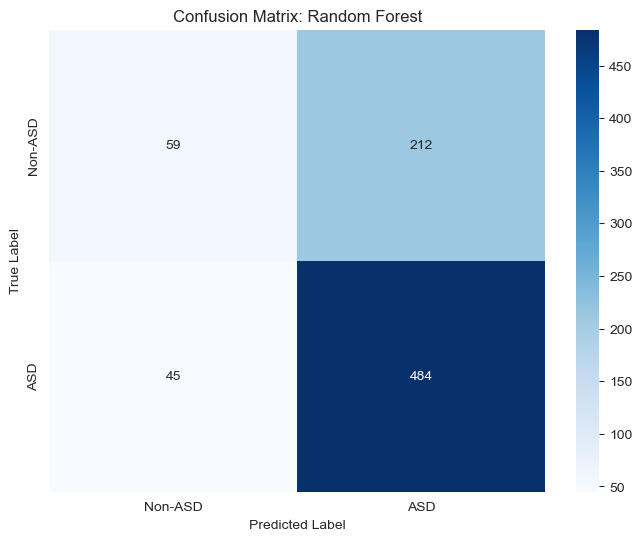

In [50]:
# Create a function to plot confusion matrix
def plot_confusion_matrix(rfc_confusion_matrix, rfc):
    plt.figure(figsize=(8, 6))

    sns.heatmap(rfc_confusion_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-ASD', 'ASD'],
                yticklabels=['Non-ASD', 'ASD'])
    plt.title(f'Confusion Matrix: {rfc}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix
rfc_confusion_matrix = confusion_matrix(y_test, pred_rfc)

# Plotting the confusion matrices
plot_confusion_matrix(rfc_confusion_matrix, 'Random Forest')

The confusion matrix shows that the Random Forest model correctly predicted 229 toddlers with ASD and incorrectly classified 27 toddlers.

# KNN

In [51]:
# Importing StandardScaler from sklearn.preprocessing to scale the variables
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler() # Instantiating the StandardScaler object

In [52]:
# Fitting the StandardScaler to the features in X and then transforming the features to a standardized scale
scaler.fit(X) # Fits the scaler to the data
scaled_features = scaler.transform(X) # Standardizes the features in X

In [53]:
# Creating a new DataFrame 'X_scaled' with the standardized features and original column names
X_scaled = pd.DataFrame(scaled_features,columns=X.columns)
# Displaying the first few rows of the scaled features DataFrame for inspection
X_scaled.head()

,within0_12,within24_36,male,Harare,Mashonaland central,Masvingo,Midlands,Matebeleland North,Matebeleland South,Mashonaland East,Bulawayo,jaundice,ASD_genes
0,-0.229476,0.845227,-1.475825,1.788737,-0.407772,-0.224603,-0.092613,-0.707637,-0.181865,-0.204177,-0.312648,1.552824,-0.437378
1,-0.229476,0.845227,0.677587,1.788737,-0.407772,-0.224603,-0.092613,-0.707637,-0.181865,-0.204177,-0.312648,-0.643988,-0.437378
2,-0.229476,0.845227,-1.475825,1.788737,-0.407772,-0.224603,-0.092613,-0.707637,-0.181865,-0.204177,-0.312648,1.552824,-0.437378
3,-0.229476,-1.183114,0.677587,1.788737,-0.407772,-0.224603,-0.092613,-0.707637,-0.181865,-0.204177,-0.312648,-0.643988,-0.437378
4,-0.229476,0.845227,0.677587,1.788737,-0.407772,-0.224603,-0.092613,-0.707637,-0.181865,-0.204177,-0.312648,-0.643988,2.286354


In [54]:
# Splitting the scaled features 'X_scaled' and the target variable 'y' into training and testing sets
# using a test size of 20% and a fixed random state for reproducibility
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.4,random_state=101)

In [55]:
# Importing the K-Nearest Neighbors Classifier from sklearn.neighbors
from sklearn.neighbors import KNeighborsClassifier
error_rate =[] # Initializing a list to store the error rates for different values of k
# Looping through a range of k values to find the optimal number of neighbors
for i in range (1,50):
    knn= KNeighborsClassifier(n_neighbors=i) # Creating a KNN classifier with i neighbors
    knn.fit(X_train,y_train) # Fitting the model on the training data
    pred_i= knn.predict(X_test) # Making predictions on the test set
    error_rate.append(np.mean(pred_i != y_test)) # Calculating and storing the error rate for this k

In [56]:
# Creating a figure with a specific size for plotting the error rates against different k values
plt.figure(figsize=(10,6))
# Creating a figure with a specific size for plotting the error rates against different k values
plt.plot(range(1,50),error_rate,color='blue',linestyle='dashed',marker='o',markerfacecolor='red',markersize=10)
# Adding a title and axis labels to the plot
plt.title('Error rate vs K-value')
plt.xlabel('K')
plt.ylabel('Error Rate')

Text(0, 0.5, 'Error Rate')

In [57]:
# creating a K-Nearest Neighbor Classifier with 13 neibours and fitting it to the training data
knn=KNeighborsClassifier(n_neighbors=13) # Instantiating a KNN classifier with 13 neighbors
knn.fit(X_train,y_train) # Instantiating a KNN classifier with 13 neighbors

KNeighborsClassifier(n_neighbors=13)

In [58]:
# Making predictions on the test set using the K-Nearest Neighbors classifier
pred_knn=knn.predict(X_test)
# Printing the confusion matrix to evaluate the performance of the KNN model
print(confusion_matrix(y_test,pred_knn))
# Generating a classification report to display precision, recall, F1-score, and support for each class
print(classification_report(y_test,pred_knn))

[[ 88 466]
 [ 65 981]]
              precision    recall  f1-score   support

       False       0.58      0.16      0.25       554
        True       0.68      0.94      0.79      1046

    accuracy                           0.67      1600
   macro avg       0.63      0.55      0.52      1600
weighted avg       0.64      0.67      0.60      1600



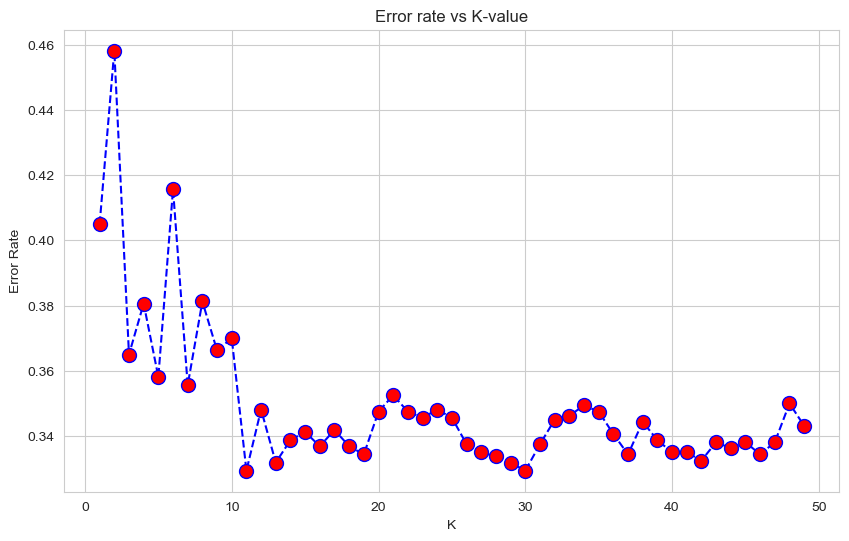

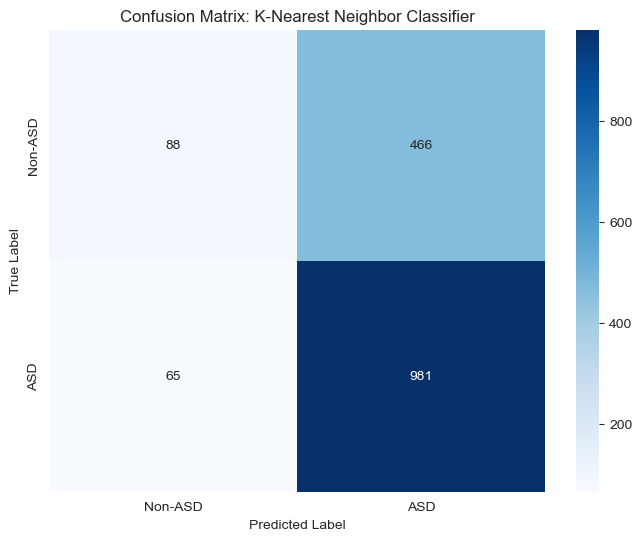

In [59]:
#function to plot confusion matrix
def plot_confusion_matrix(knn_confusion_matrix, knn):
    plt.figure(figsize=(8, 6))

    sns.heatmap(knn_confusion_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-ASD', 'ASD'],
                yticklabels=['Non-ASD', 'ASD'])
    plt.title(f'Confusion Matrix: {knn}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix
knn_confusion_matrix = confusion_matrix(y_test, pred_knn)

# Plotting the confusion matrices
plot_confusion_matrix(knn_confusion_matrix, 'K-Nearest Neighbor Classifier')

The confusion matrix shows that the KNN classification model correctly predicted 214 toddlers with ASD and incorrectly classified 42 toddlers.

#### These results indicate that while both models are viable for ASD prediction, the Random Forest model outperformed the KNN model in terms of accuracy. The ability to correctly classify a higher number of ASD cases is crucial for early detection and intervention, potentially leading to better outcomes for affected children.

####The findings underscore the importance of selecting appropriate machine learning techniques tailored to the specific characteristics of the dataset and the problem at hand. As such, the Random Forest model may be recommended for future applications in ASD prediction, while also suggesting that further refinement and validation of these models could enhance their predictive capabilities. Continued research and development in this area will contribute significantly to improving early detection strategies for ASD, ultimately benefiting families and healthcare providers alike.
#### So based on the KNN classifier model on above dataset, if any parent provides toddler's age,gender,ethnicity,jaundice while birth? and any relative having ASD traits?, the model can predict either the toddler has ASD or not with precision of 71%

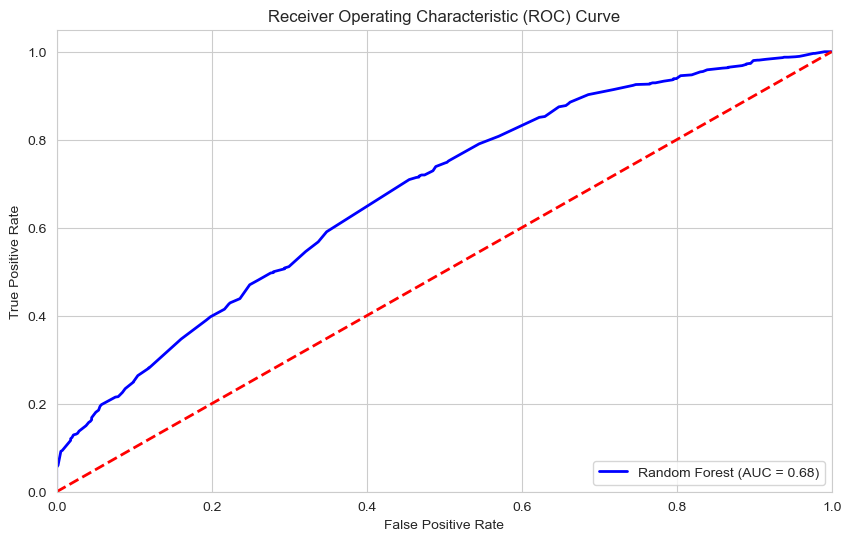

In [60]:
#MODEL PERFORMANCE COMPARISON

#ROC Curve for Random Forest Classifier
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rfc.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='Random Forest (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

A ROC AUC score of 0.57 for a random classifier indicates that the model's ability to distinguish between the positive and negative classes is only slightly better than random guessing. This score is close to 0.5, which represents the performance of a classifier that makes predictions at random without any learned information from the data.

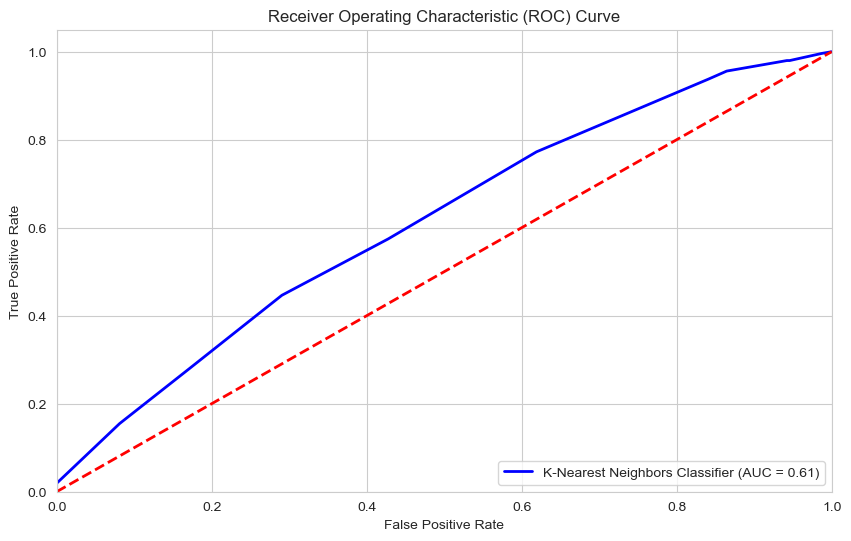

In [61]:
#ROC Curve for knn
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, knn.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='K-Nearest Neighbors Classifier (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

A ROC AUC score of 0.52 for the K-Nearest Neighbors (KNN) classifier indicates that the model's performance is just barely better than random guessing. This score is very close to 0.5, which suggests that the classifier is struggling to effectively differentiate between the positive and negative classes.

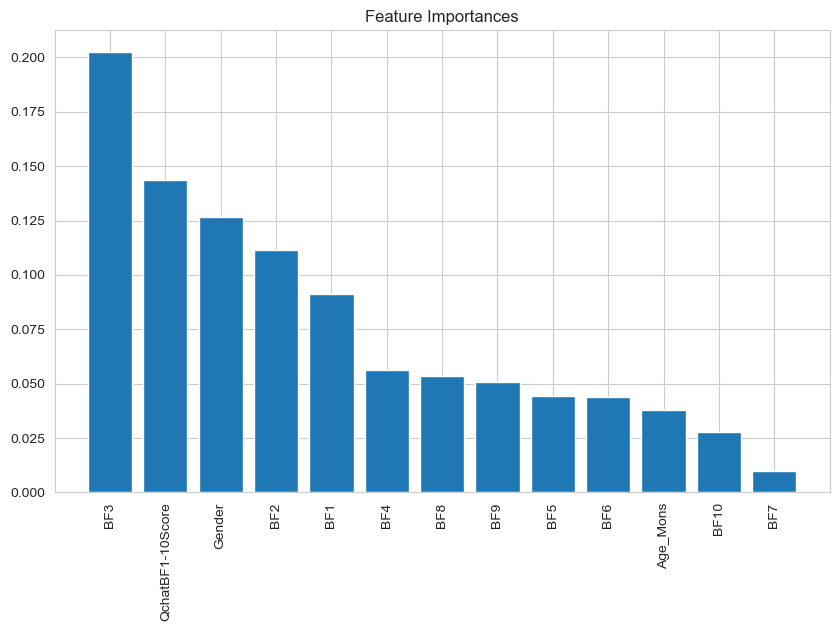

In [62]:
# For Random Forest
feature_importances = rfc.feature_importances_
indices = np.argsort(feature_importances)[::-1]

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), feature_importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), np.array(Data.columns[indices]), rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

It is clear that BF3 is the most important feature while BF7 is the least important.

Fitting 5 folds for each of 294 candidates, totalling 1470 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 47, 'weights': 'distance'}
Best Cross-Validation Accuracy: 0.7097538274182325

Confusion Matrix:
[[101 453]
 [ 68 978]]

Classification Report:
              precision    recall  f1-score   support

       False       0.60      0.18      0.28       554
        True       0.68      0.93      0.79      1046

    accuracy                           0.67      1600
   macro avg       0.64      0.56      0.53      1600
weighted avg       0.65      0.67      0.61      1600



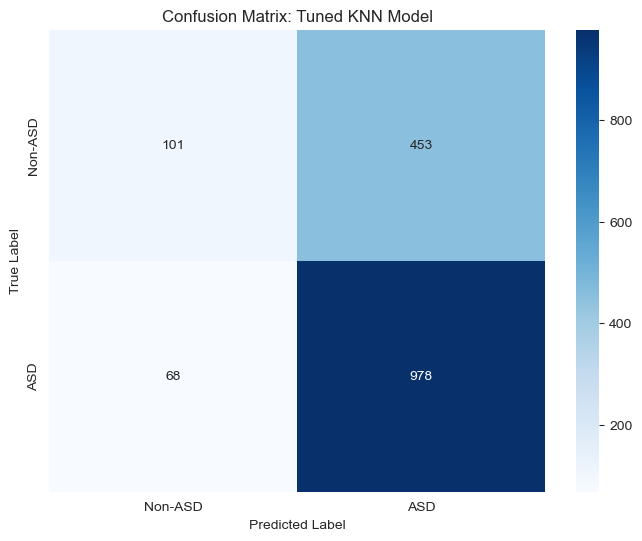

Test Set Accuracy: 0.67


In [63]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the parameter grid for KNN
param_grid = {
    'n_neighbors': range(1, 50),       # Number of neighbors to test
    'weights': ['uniform', 'distance'], # Weight function used in prediction
    'metric': ['euclidean', 'manhattan', 'minkowski'] # Distance metrics
}

# Instantiate the KNN classifier
knn = KNeighborsClassifier()

# Set up GridSearchCV with cross-validation
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Use the best estimator for predictions
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)

# Evaluate the model
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-ASD', 'ASD'],
            yticklabels=['Non-ASD', 'ASD'])
plt.title('Confusion Matrix: Tuned KNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.2f}")


Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Parameters: {'bootstrap': False, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.6979308489827856

Confusion Matrix:
[[ 51 220]
 [ 36 493]]

Classification Report:
              precision    recall  f1-score   support

       False       0.59      0.19      0.28       271
        True       0.69      0.93      0.79       529

    accuracy                           0.68       800
   macro avg       0.64      0.56      0.54       800
weighted avg       0.66      0.68      0.62       800



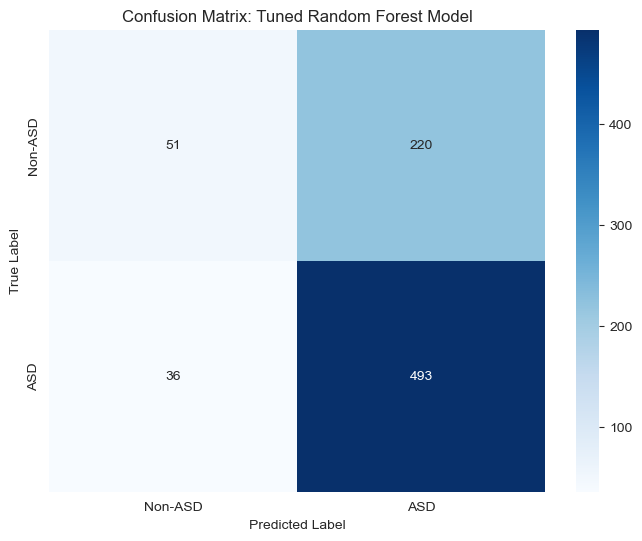

Test Set Accuracy: 0.68


In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 500, 1000, 1500],        # Number of trees in the forest
    'max_depth': [10, 20, 30, None],               # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],               # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],                 # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False]                     # Whether bootstrap samples are used when building trees
}

# Instantiate the Random Forest Classifier
rfc = RandomForestClassifier(random_state=101)

# Set up GridSearchCV with cross-validation
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Retrieve the best parameters and the best model
best_params = grid_search.best_params_
rfc_best = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate the best model on the test set
y_pred = rfc_best.predict(X_test)

# Print the confusion matrix and classification report
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-ASD', 'ASD'],
            yticklabels=['Non-ASD', 'ASD'])
plt.title('Confusion Matrix: Tuned Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Calculate and print the test set accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.2f}")


                     Importance
male                   0.252386
jaundice               0.166263
ASD_genes              0.120902
within0_12             0.107243
within24_36            0.100212
Matebeleland South     0.048277
Matebeleland North     0.040762
Harare                 0.040615
Masvingo               0.036471
Mashonaland central    0.034359
Bulawayo               0.031741
Mashonaland East       0.016460
Midlands               0.004310


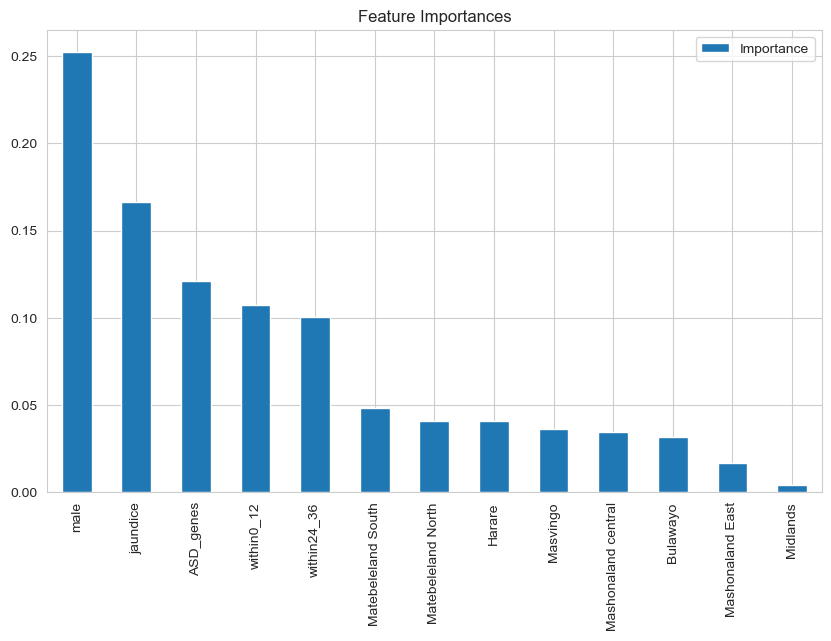

In [65]:
# Extract and plot feature importance
import pandas as pd
feature_importances = pd.DataFrame(rfc_best.feature_importances_,
                                   index=X.columns,
                                   columns=['Importance']).sort_values(by='Importance', ascending=False)
print(feature_importances)

# Visualize feature importance
feature_importances.plot(kind='bar', figsize=(10, 6), title="Feature Importances")
plt.show()


In [66]:
top_features = feature_importances[feature_importances['Importance'] > 0.02].index
X_train_reduced = X_train[top_features]
X_test_reduced = X_test[top_features]

# Re-train the model with the reduced features
rfc_reduced = RandomForestClassifier(random_state=101, **best_params)
rfc_reduced.fit(X_train_reduced, y_train)

# Evaluate the reduced model
y_pred_reduced = rfc_reduced.predict(X_test_reduced)
print("Reduced Model Accuracy:", accuracy_score(y_test, y_pred_reduced))
print(confusion_matrix(y_test, y_pred_reduced))
print(classification_report(y_test, y_pred_reduced))


Reduced Model Accuracy: 0.67875
[[ 52 219]
 [ 38 491]]
              precision    recall  f1-score   support

       False       0.58      0.19      0.29       271
        True       0.69      0.93      0.79       529

    accuracy                           0.68       800
   macro avg       0.63      0.56      0.54       800
weighted avg       0.65      0.68      0.62       800

